# Healthcare Hospital Ratings Analysis

## Project Overview

This project analyzes publicly available hospital data from the Centers for Medicare & Medicaid Services (CMS) to explore patterns in hospital ratings, hospital type, ownership, and geographic variation.

The analysis demonstrates practical healthcare analytics skills including:

- Data loading and preparation
- Data quality assessment
- Missing-data analysis
- Exploratory data analysis
- Grouped analysis and aggregation
- Healthcare KPI analysis
- Data visualization
- Interpretation of healthcare operational data

## Business Question

How do hospital ratings vary across hospital types, ownership structures, and states, and what patterns can be identified from the available CMS data?

## Dataset

The analysis uses the CMS Hospital General Information dataset, which contains hospital-level information including:

- Hospital type
- Hospital ownership
- Overall hospital rating
- Location
- Mortality measures
- Readmission measures
- Patient experience measures
- Safety measures
- Timeliness measures

## Objective

The goal is not simply to calculate statistics, but to use healthcare data to identify meaningful patterns, evaluate data quality, and communicate findings that could support healthcare operations and performance improvement decisions.

# 1. Data Quality Assessment

Before analyzing hospital ratings, I assessed the dataset for missing values, duplicate records, and overall data completeness.

This step is important because missing or unavailable data can affect how healthcare performance measures are interpreted.

### Data Quality Findings

The dataset contains 5,419 hospital records and 38 variables.

Seven variables contain substantial missing or unavailable values, primarily related to measure-specific footnotes and designation information. Core identifying and classification fields such as hospital name, facility ID, location, hospital type, ownership, and overall rating are populated.

The dataset contains no duplicate hospital records.

The overall hospital rating field contains five rating levels (1–5), as well as records where a rating is listed as "Not Available." Approximately 41.4% of hospitals do not have an available overall rating in this dataset.

Because a substantial portion of hospitals does not have an overall rating, subsequent analyses of average ratings exclude records where the rating is unavailable.

In [ ]:
import pandas as pd

hospital_df = pd.read_csv('/content/Hospital_General_Information.csv')

hospital_df.head()


,Facility ID,Facility Name,Address,City/Town,State,ZIP Code,County/Parish,Telephone Number,Hospital Type,Hospital Ownership,...,Count of READM Measures Better,Count of READM Measures No Different,Count of READM Measures Worse,READM Group Footnote,Pt Exp Group Measure Count,Count of Facility Pt Exp Measures,Pt Exp Group Footnote,TE Group Measure Count,Count of Facility TE Measures,TE Group Footnote
0,010001,SOUTHEAST HEALTH MEDICAL CENTER,1108 ROSS CLARK CIRCLE,DOTHAN,AL,36301,HOUSTON,(334) 793-8701,Acute Care Hospitals,Government - Hospital District or Authority,...,1,9,1,NaN,15,15,NaN,10,10,NaN
1,010005,MARSHALL MEDICAL CENTERS,2505 U S HIGHWAY 431 NORTH,BOAZ,AL,35957,MARSHALL,(256) 593-8310,Acute Care Hospitals,Government - Hospital District or Authority,...,1,8,0,NaN,15,15,NaN,10,10,NaN
2,010006,NORTH ALABAMA MEDICAL CENTER,1701 VETERANS DRIVE,FLORENCE,AL,35630,LAUDERDALE,(256) 768-8400,Acute Care Hospitals,Proprietary,...,1,8,0,NaN,15,15,NaN,10,9,NaN
3,010007,MIZELL MEMORIAL HOSPITAL,702 N MAIN ST,OPP,AL,36467,COVINGTON,(334) 493-3541,Acute Care Hospitals,Voluntary non-profit - Private,...,0,3,2,NaN,15,5,NaN,10,7,NaN
4,010011,ST. VINCENT'S EAST,50 MEDICAL PARK EAST DRIVE,BIRMINGHAM,AL,35235,JEFFERSON,(205) 838-3122,Acute Care Hospitals,Voluntary non-profit - Private,...,1,5,2,29.0,15,10,29.0,10,7,29.0


In [ ]:
print("Rows:", hospital_df.shape[0])
print("Columns:", hospital_df.shape[1])

Rows: 5419
Columns: 38


In [ ]:
hospital_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5419 entries, 0 to 5418
Data columns (total 38 columns):
 #   Column                                            Non-Null Count  Dtype  
---  ------                                            --------------  -----  
 0   Facility ID                                       5419 non-null   object 
 1   Facility Name                                     5419 non-null   object 
 2   Address                                           5419 non-null   object 
 3   City/Town                                         5419 non-null   object 
 4   State                                             5419 non-null   object 
 5   ZIP Code                                          5419 non-null   int64  
 6   County/Parish                                     5419 non-null   object 
 7   Telephone Number                                  5419 non-null   object 
 8   Hospital Type                                     5419 non-null   object 
 9   Hospital Ownership 

In [ ]:
for column in hospital_df.columns:
    print(column)

Facility ID
Facility Name
Address
City/Town
State
ZIP Code
County/Parish
Telephone Number
Hospital Type
Hospital Ownership
Emergency Services
Meets criteria for birthing friendly designation
Hospital overall rating
Hospital overall rating footnote
MORT Group Measure Count
Count of Facility MORT Measures
Count of MORT Measures Better
Count of MORT Measures No Different
Count of MORT Measures Worse
MORT Group Footnote
Safety Group Measure Count
Count of Facility Safety Measures
Count of Safety Measures Better
Count of Safety Measures No Different
Count of Safety Measures Worse
Safety Group Footnote
READM Group Measure Count
Count of Facility READM Measures
Count of READM Measures Better
Count of READM Measures No Different
Count of READM Measures Worse
READM Group Footnote
Pt Exp Group Measure Count
Count of Facility Pt Exp Measures
Pt Exp Group Footnote
TE Group Measure Count
Count of Facility TE Measures
TE Group Footnote


In [ ]:
print(hospital_df.columns.tolist())

['Facility ID', 'Facility Name', 'Address', 'City/Town', 'State', 'ZIP Code', 'County/Parish', 'Telephone Number', 'Hospital Type', 'Hospital Ownership', 'Emergency Services', 'Meets criteria for birthing friendly designation', 'Hospital overall rating', 'Hospital overall rating footnote', 'MORT Group Measure Count', 'Count of Facility MORT Measures', 'Count of MORT Measures Better', 'Count of MORT Measures No Different', 'Count of MORT Measures Worse', 'MORT Group Footnote', 'Safety Group Measure Count', 'Count of Facility Safety Measures', 'Count of Safety Measures Better', 'Count of Safety Measures No Different', 'Count of Safety Measures Worse', 'Safety Group Footnote', 'READM Group Measure Count', 'Count of Facility READM Measures', 'Count of READM Measures Better', 'Count of READM Measures No Different', 'Count of READM Measures Worse', 'READM Group Footnote', 'Pt Exp Group Measure Count', 'Count of Facility Pt Exp Measures', 'Pt Exp Group Footnote', 'TE Group Measure Count', 'Co

In [ ]:
print("Number of columns:", len(hospital_df.columns))

Number of columns: 38


In [ ]:
print(hospital_df.dtypes)

Facility ID                                          object
Facility Name                                        object
Address                                              object
City/Town                                            object
State                                                object
ZIP Code                                              int64
County/Parish                                        object
Telephone Number                                     object
Hospital Type                                        object
Hospital Ownership                                   object
Emergency Services                                   object
Meets criteria for birthing friendly designation     object
Hospital overall rating                              object
Hospital overall rating footnote                     object
MORT Group Measure Count                             object
Count of Facility MORT Measures                      object
Count of MORT Measures Better           

In [ ]:
hospital_df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Facility ID,5419,5419,671304,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Facility Name,5419,5288,MEMORIAL HOSPITAL,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Address,5419,5382,100 HOSPITAL DRIVE,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN
City/Town,5419,3046,CHICAGO,33,NaN,NaN,NaN,NaN,NaN,NaN,NaN
State,5419,56,TX,467,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ZIP Code,5419.0,NaN,NaN,NaN,53847.149843,27048.532955,603.0,32796.0,55103.0,76112.5,99929.0
County/Parish,5419,1557,LOS ANGELES,88,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Telephone Number,5419,5376,(469) 341-7800,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Hospital Type,5419,8,Acute Care Hospitals,3107,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Hospital Ownership,5419,12,Voluntary non-profit - Private,2322,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
missing = hospital_df.isnull().sum()

missing = missing[missing > 0].sort_values(ascending=False)

missing

,0
TE Group Footnote,4411
READM Group Footnote,4196
MORT Group Footnote,4023
Pt Exp Group Footnote,3403
Safety Group Footnote,3270
Meets criteria for birthing friendly designation,3156
Hospital overall rating footnote,3103


In [ ]:
hospital_df.duplicated().sum()

np.int64(0)

In [ ]:
hospital_df.iloc[:, 0].nunique()

5419

In [ ]:
hospital_df.isna().sum().sort_values(ascending=False)

,0
TE Group Footnote,4411
READM Group Footnote,4196
MORT Group Footnote,4023
Pt Exp Group Footnote,3403
Safety Group Footnote,3270
Meets criteria for birthing friendly designation,3156
Hospital overall rating footnote,3103
State,0
ZIP Code,0
Address,0


In [ ]:
hospital_df.shape

(5419, 38)

In [ ]:
hospital_df["Hospital overall rating"].value_counts().sort_index()

,count
Hospital overall rating,
1,198
2,661
3,985
4,946
5,384
Not Available,2245


In [ ]:
hospital_df["Hospital overall rating"].value_counts(normalize=True).sort_index() * 100

,proportion
Hospital overall rating,
1,3.653811
2,12.197822
3,18.176785
4,17.457095
5,7.086178
Not Available,41.428308


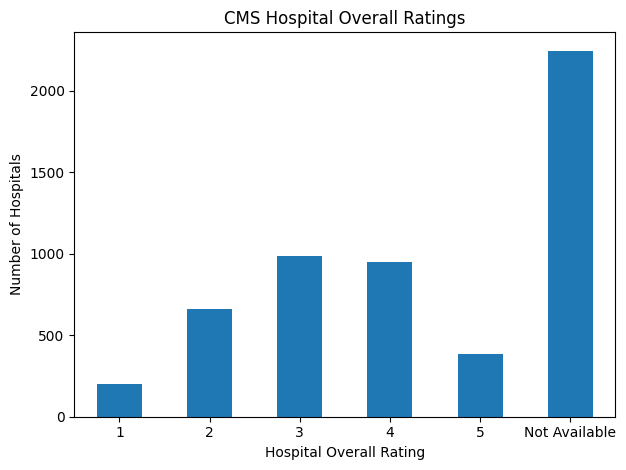

In [ ]:
import matplotlib.pyplot as plt

rating_counts = hospital_df["Hospital overall rating"].value_counts()

rating_order = ["1", "2", "3", "4", "5", "Not Available"]

rating_counts = rating_counts.reindex(rating_order)

rating_counts.plot(kind="bar")

plt.title("CMS Hospital Overall Ratings")
plt.xlabel("Hospital Overall Rating")
plt.ylabel("Number of Hospitals")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
rating_by_type = pd.crosstab(
    hospital_df["Hospital Type"],
    hospital_df["Hospital overall rating"]
)

rating_by_type

Hospital overall rating,1,2,3,4,5,Not Available
Hospital Type,,,,,,
Acute Care - Department of Defense,0,0,0,0,0,32
Acute Care - Veterans Administration,0,7,18,37,50,20
Acute Care Hospitals,175,572,846,780,290,444
Childrens,0,0,0,0,0,94
Critical Access Hospitals,23,82,121,129,44,983
Long-term,0,0,0,0,0,5
Psychiatric,0,0,0,0,0,624
Rural Emergency Hospital,0,0,0,0,0,43


In [ ]:
rating_by_ownership = pd.crosstab(
    hospital_df["Hospital Ownership"],
    hospital_df["Hospital overall rating"]
)

rating_by_ownership

Hospital overall rating,1,2,3,4,5,Not Available
Hospital Ownership,,,,,,
Department of Defense,0,0,0,0,0,32
Government - Federal,0,5,3,3,0,31
Government - Hospital District or Authority,19,63,80,50,16,284
Government - Local,20,45,54,49,11,214
Government - State,5,11,10,8,4,171
Physician,0,2,7,4,5,62
Proprietary,51,168,143,115,25,561
Tribal,0,0,1,0,2,14
Veterans Health Administration,0,7,18,37,50,20


In [ ]:
rating_by_type_pct = pd.crosstab(
    hospital_df["Hospital Type"],
    hospital_df["Hospital overall rating"],
    normalize="index"
) * 100

rating_by_type_pct.round(1)

Hospital overall rating,1,2,3,4,5,Not Available
Hospital Type,,,,,,
Acute Care - Department of Defense,0.0,0.0,0.0,0.0,0.0,100.0
Acute Care - Veterans Administration,0.0,5.3,13.6,28.0,37.9,15.2
Acute Care Hospitals,5.6,18.4,27.2,25.1,9.3,14.3
Childrens,0.0,0.0,0.0,0.0,0.0,100.0
Critical Access Hospitals,1.7,5.9,8.8,9.3,3.2,71.1
Long-term,0.0,0.0,0.0,0.0,0.0,100.0
Psychiatric,0.0,0.0,0.0,0.0,0.0,100.0
Rural Emergency Hospital,0.0,0.0,0.0,0.0,0.0,100.0


In [ ]:
rating_by_type_pct["Not Available"].sort_values(ascending=False)

,Not Available
Hospital Type,
Acute Care - Department of Defense,100.000000
Childrens,100.000000
Psychiatric,100.000000
Long-term,100.000000
Rural Emergency Hospital,100.000000
Critical Access Hospitals,71.128799
Acute Care - Veterans Administration,15.151515
Acute Care Hospitals,14.290312


In [ ]:
rated_hospitals = hospital_df[
    hospital_df["Hospital overall rating"] != "Not Available"
].copy()

rated_hospitals.shape

(3174, 38)

In [ ]:
rated_hospitals["Hospital overall rating"].value_counts().sort_index()

,count
Hospital overall rating,
1,198
2,661
3,985
4,946
5,384


# 2. Hospital Ratings by Hospital Type

## Question

How does average hospital rating vary by hospital type?

To answer this question, I calculated the average overall hospital rating for each hospital type after excluding hospitals where an overall rating was not available.

## Findings

Among hospital types with available ratings, Veterans Administration acute care hospitals had the highest average rating at approximately 4.16, followed by Critical Access Hospitals at approximately 3.22 and Acute Care Hospitals at approximately 3.16.

Several hospital categories did not have sufficient rated records in this dataset to calculate a meaningful average. These categories were therefore excluded from interpretation rather than treating missing values as zero.

## Interpretation

Hospital type appears to be associated with differences in average overall ratings. However, the results should be interpreted cautiously because the number of hospitals and availability of ratings vary substantially between hospital types.

This demonstrates the importance of considering sample size and data availability when comparing healthcare performance measures.

In [ ]:
rated_hospitals.groupby("Hospital Type")["Hospital overall rating"].apply(
    lambda x: pd.to_numeric(x).mean()
).sort_values(ascending=False)

,Hospital overall rating
Hospital Type,
Acute Care - Veterans Administration,4.160714
Critical Access Hospitals,3.223058
Acute Care Hospitals,3.164476


In [ ]:
rated_hospitals["Hospital Ownership"].value_counts()

,count
Hospital Ownership,
Voluntary non-profit - Private,1619
Proprietary,502
Voluntary non-profit - Other,246
Government - Hospital District or Authority,228
Voluntary non-profit - Church,218
Government - Local,179
Veterans Health Administration,112
Government - State,38
Physician,18


# 3. Hospital Ratings by Ownership

## Question

Does average hospital rating vary across hospital ownership structures?

To examine this relationship, I calculated the average overall hospital rating for each ownership category using hospitals with an available rating.

## Findings

Among ownership categories with available ratings, Tribal hospitals had the highest average rating at approximately 4.33, followed by Veterans Health Administration hospitals at approximately 4.16 and Physician-owned hospitals at approximately 3.67.

Voluntary nonprofit organizations generally had higher average ratings than proprietary hospitals in this dataset. Proprietary hospitals had an average rating of approximately 2.79.

## Important Limitation

The number of hospitals varies considerably across ownership categories. For example, the Tribal category contains only three rated hospitals, while voluntary nonprofit and proprietary categories contain substantially more.

Therefore, the average rating alone should not be interpreted as evidence that one ownership structure causes better or worse hospital performance.

## Interpretation

The analysis identifies differences in hospital ratings across ownership categories and demonstrates the importance of considering both performance measures and sample size when evaluating healthcare organizations.

In [ ]:
ownership_avg = rated_hospitals.groupby(
    "Hospital Ownership"
)["Hospital overall rating"].apply(
    lambda x: pd.to_numeric(x).mean()
).sort_values(ascending=False)

ownership_avg

,Hospital overall rating
Hospital Ownership,
Tribal,4.333333
Veterans Health Administration,4.160714
Physician,3.666667
Voluntary non-profit - Church,3.380734
Voluntary non-profit - Private,3.307597
Voluntary non-profit - Other,3.304878
Government - Local,2.921788
Government - Hospital District or Authority,2.916667
Government - State,2.868421


In [ ]:
hospital_df["Hospital overall rating numeric"] = pd.to_numeric(
    hospital_df["Hospital overall rating"],
    errors="coerce"
)

In [ ]:
avg_rating_by_type = (
    hospital_df
    .groupby("Hospital Type")["Hospital overall rating numeric"]
    .mean()
    .sort_values(ascending=False)
)

In [ ]:
hospital_df["Hospital overall rating numeric"].value_counts(dropna=False)

,count
Hospital overall rating numeric,
NaN,2245
3.0,985
4.0,946
2.0,661
5.0,384
1.0,198


In [ ]:
avg_rating_by_type

,Hospital overall rating numeric
Hospital Type,
Acute Care - Veterans Administration,4.160714
Critical Access Hospitals,3.223058
Acute Care Hospitals,3.164476
Acute Care - Department of Defense,NaN
Childrens,NaN
Long-term,NaN
Psychiatric,NaN
Rural Emergency Hospital,NaN


In [ ]:
hospital_type_analysis = (
    hospital_df
    .groupby("Hospital Type")["Hospital overall rating numeric"]
    .agg(["count", "mean"])
    .sort_values("mean", ascending=False)
)

hospital_type_analysis

,count,mean
Hospital Type,,
Acute Care - Veterans Administration,112,4.160714
Critical Access Hospitals,399,3.223058
Acute Care Hospitals,2663,3.164476
Acute Care - Department of Defense,0,NaN
Childrens,0,NaN
Long-term,0,NaN
Psychiatric,0,NaN
Rural Emergency Hospital,0,NaN


In [ ]:
ownership_analysis = (
    hospital_df
    .groupby("Hospital Ownership")["Hospital overall rating numeric"]
    .agg(["count", "mean"])
    .sort_values("mean", ascending=False)
)

In [ ]:
ownership_analysis

,count,mean
Hospital Ownership,,
Tribal,3,4.333333
Veterans Health Administration,112,4.160714
Physician,18,3.666667
Voluntary non-profit - Church,218,3.380734
Voluntary non-profit - Private,1619,3.307597
Voluntary non-profit - Other,246,3.304878
Government - Local,179,2.921788
Government - Hospital District or Authority,228,2.916667
Government - State,38,2.868421


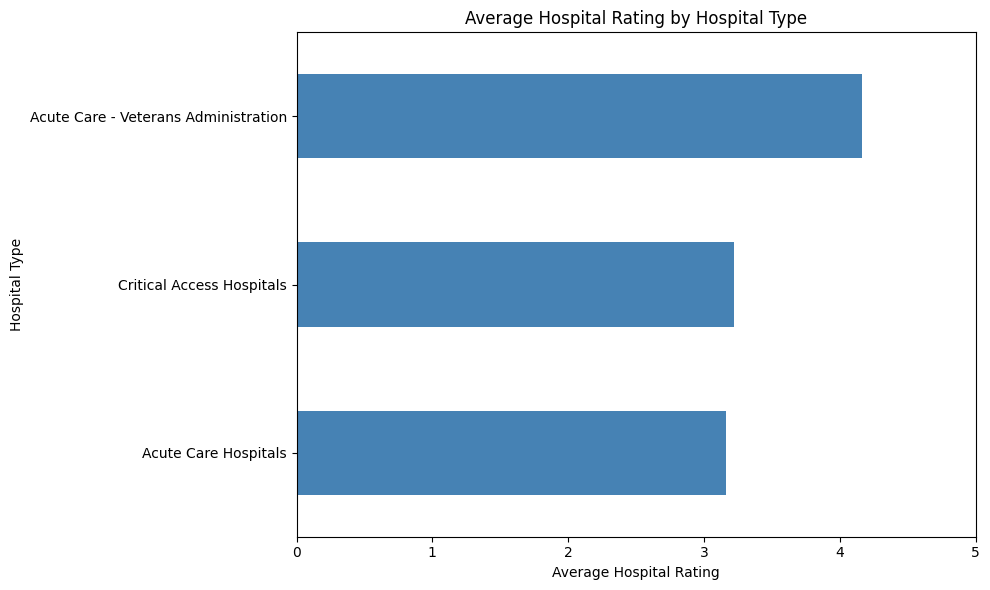

In [ ]:
import matplotlib.pyplot as plt

rating_by_type = (
    hospital_df.dropna(subset=["Hospital overall rating numeric"])
    .groupby("Hospital Type")["Hospital overall rating numeric"]
    .mean()
    .sort_values(ascending=True)
)

rating_by_type.plot(
    kind="barh",
    figsize=(10, 6),
    color="steelblue"
)

plt.title("Average Hospital Rating by Hospital Type")
plt.xlabel("Average Hospital Rating")
plt.ylabel("Hospital Type")
plt.xlim(0, 5)
plt.tight_layout()
plt.show()

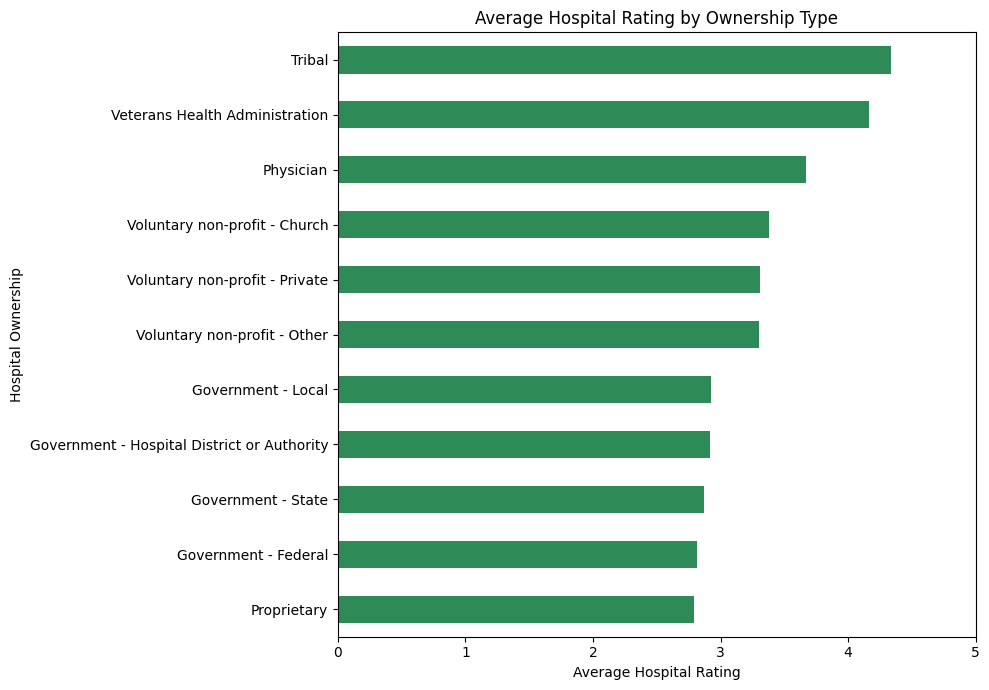

In [ ]:
rating_by_ownership = (
    hospital_df.dropna(subset=["Hospital overall rating numeric"])
    .groupby("Hospital Ownership")["Hospital overall rating numeric"]
    .mean()
    .sort_values(ascending=True)
)

rating_by_ownership.plot(
    kind="barh",
    figsize=(10, 7),
    color="seagreen"
)

plt.title("Average Hospital Rating by Ownership Type")
plt.xlabel("Average Hospital Rating")
plt.ylabel("Hospital Ownership")
plt.xlim(0, 5)
plt.tight_layout()
plt.show()

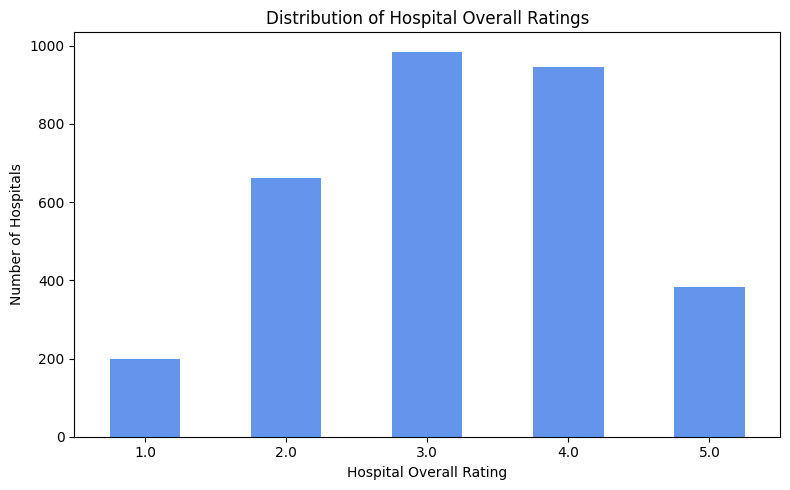

In [ ]:
rating_counts = (
    hospital_df["Hospital overall rating numeric"]
    .value_counts()
    .sort_index()
)

rating_counts.plot(
    kind="bar",
    figsize=(8, 5),
    color="cornflowerblue"
)

plt.title("Distribution of Hospital Overall Ratings")
plt.xlabel("Hospital Overall Rating")
plt.ylabel("Number of Hospitals")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

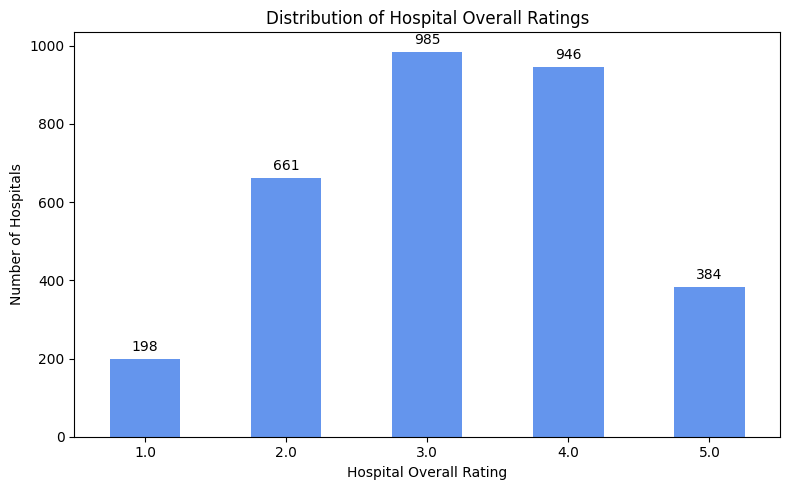

In [ ]:
rating_counts = (
    hospital_df["Hospital overall rating numeric"]
    .value_counts()
    .sort_index()
)

ax = rating_counts.plot(
    kind="bar",
    figsize=(8, 5),
    color="cornflowerblue"
)

plt.title("Distribution of Hospital Overall Ratings")
plt.xlabel("Hospital Overall Rating")
plt.ylabel("Number of Hospitals")
plt.xticks(rotation=0)

for i, value in enumerate(rating_counts):
    ax.text(i, value + 20, str(value), ha="center")

plt.tight_layout()
plt.show()

In [ ]:
rating_availability = (
    hospital_df["Hospital overall rating"]
    .value_counts()
    .rename(index={"Not Available": "Not Available"})
)

rating_available = hospital_df["Hospital overall rating"].notna().sum()

print("Total hospitals:", len(hospital_df))
print("Hospitals with a rating:", rating_available)
print("Hospitals without a rating:", len(hospital_df) - rating_available)

Total hospitals: 5419
Hospitals with a rating: 5419
Hospitals without a rating: 0


In [ ]:
total_hospitals = len(hospital_df)

rated_hospitals = (
    hospital_df["Hospital overall rating"] != "Not Available"
).sum()

unrated_hospitals = total_hospitals - rated_hospitals

print("Total hospitals:", total_hospitals)
print("Hospitals with a rating:", rated_hospitals)
print("Hospitals without a rating:", unrated_hospitals)

print(
    "Percentage without a rating:",
    round((unrated_hospitals / total_hospitals) * 100, 1),
    "%"
)

Total hospitals: 5419
Hospitals with a rating: 3174
Hospitals without a rating: 2245
Percentage without a rating: 41.4 %


# 4. Geographic Variation in Hospital Ratings

## Question

How do average hospital ratings vary across states?

To examine geographic variation, I calculated the average overall hospital rating for each state using hospitals with an available rating. States were then ranked by their average rating.

## Findings

The highest average ratings among the states represented in the analysis were observed in:

- Utah — 4.24
- Colorado — 3.96
- South Dakota — 3.89
- Wisconsin — 3.78
- Minnesota — 3.77
- Virginia — 3.68
- Ohio — 3.58
- Idaho — 3.55
- Rhode Island — 3.55
- Nebraska — 3.50

## Interpretation

The results indicate geographic variation in average hospital ratings. However, state-level averages should not be interpreted as evidence that hospitals in one state are inherently higher quality than those in another.

Differences in hospital type, ownership, hospital size, patient population, and the availability of ratings may contribute to the observed variation.

This analysis demonstrates how geographic segmentation can be used to identify patterns that may warrant additional investigation.

In [ ]:
state_rating = (
    hospital_df.dropna(subset=["Hospital overall rating numeric"])
    .groupby("State")
    .agg(
        Hospitals=("Hospital overall rating numeric", "count"),
        Average_Rating=("Hospital overall rating numeric", "mean")
    )
    .sort_values("Average_Rating", ascending=False)
)

state_rating.head(10)

,Hospitals,Average_Rating
State,,
UT,29,4.241379
CO,49,3.959184
SD,18,3.888889
WI,86,3.779070
MN,56,3.767857
VA,76,3.684211
OH,128,3.578125
RI,11,3.545455
ID,22,3.545455


In [ ]:
state_analysis = (
    hospital_df[hospital_df["Hospital overall rating numeric"].notna()]
    .groupby("State")["Hospital overall rating numeric"]
    .agg(["count", "mean"])
    .sort_values("mean", ascending=False)
)

print(state_analysis.head(10))
print()
print(state_analysis.tail(10))

       count      mean
State                 
UT        29  4.241379
CO        49  3.959184
SD        18  3.888889
WI        86  3.779070
MN        56  3.767857
VA        76  3.684211
OH       128  3.578125
RI        11  3.545455
ID        22  3.545455
NE        36  3.500000

       count      mean
State                 
LA        59  2.813559
NY       136  2.772059
WV        34  2.764706
KY        67  2.761194
AL        58  2.741379
NM        23  2.478261
MS        52  2.326923
GU         1  2.000000
PR         7  1.714286
VI         2  1.500000


In [ ]:
state_analysis_10plus = (
    hospital_df[hospital_df["Hospital overall rating numeric"].notna()]
    .groupby("State")["Hospital overall rating numeric"]
    .agg(["count", "mean"])
)

state_analysis_10plus = (
    state_analysis_10plus[state_analysis_10plus["count"] >= 10]
    .sort_values("mean", ascending=False)
)

print(state_analysis_10plus.head(10))

       count      mean
State                 
UT        29  4.241379
CO        49  3.959184
SD        18  3.888889
WI        86  3.779070
MN        56  3.767857
VA        76  3.684211
OH       128  3.578125
ID        22  3.545455
RI        11  3.545455
NE        36  3.500000


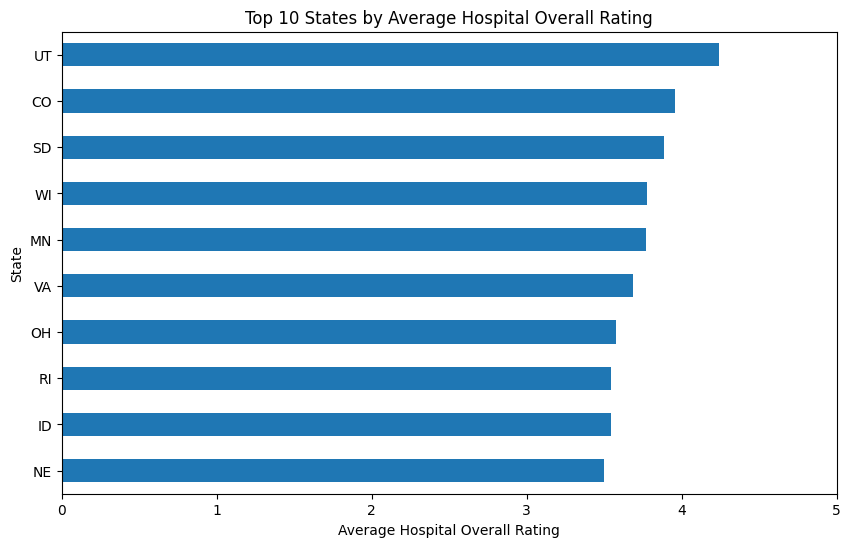

In [ ]:
top_states = state_analysis_10plus.head(10).sort_values("mean")

top_states["mean"].plot(
    kind="barh",
    figsize=(10, 6),
    title="Top 10 States by Average Hospital Overall Rating"
)

plt.xlabel("Average Hospital Overall Rating")
plt.ylabel("State")
plt.xlim(0, 5)
plt.show()

In [ ]:
top_states = state_analysis_10plus.head(10)

print(top_states)

       count      mean
State                 
UT        29  4.241379
CO        49  3.959184
SD        18  3.888889
WI        86  3.779070
MN        56  3.767857
VA        76  3.684211
OH       128  3.578125
ID        22  3.545455
RI        11  3.545455
NE        36  3.500000


In [ ]:
ownership_analysis = (
    hospital_df[hospital_df["Hospital overall rating numeric"].notna()]
    .groupby("Hospital Ownership")["Hospital overall rating numeric"]
    .agg(["count", "mean"])
    .sort_values("mean", ascending=False)
)

print(ownership_analysis)

                                             count      mean
Hospital Ownership                                          
Tribal                                           3  4.333333
Veterans Health Administration                 112  4.160714
Physician                                       18  3.666667
Voluntary non-profit - Church                  218  3.380734
Voluntary non-profit - Private                1619  3.307597
Voluntary non-profit - Other                   246  3.304878
Government - Local                             179  2.921788
Government - Hospital District or Authority    228  2.916667
Government - State                              38  2.868421
Government - Federal                            11  2.818182
Proprietary                                    502  2.790837


In [ ]:
ownership_20plus = ownership_analysis[
    ownership_analysis["count"] >= 20
].sort_values("mean")

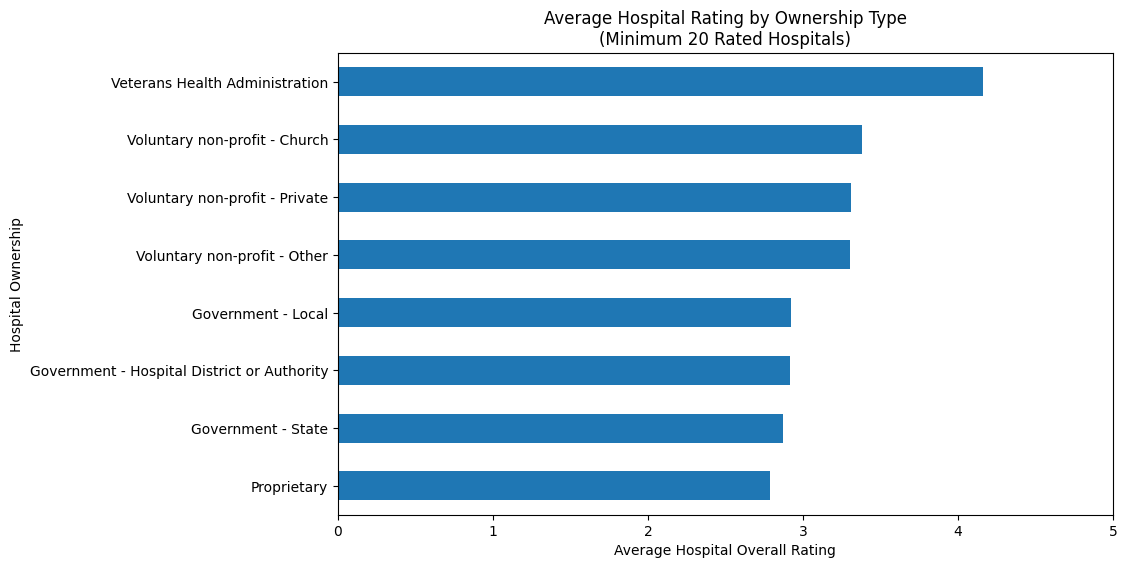

In [ ]:
ownership_20plus["mean"].plot(
    kind="barh",
    figsize=(10, 6),
    title="Average Hospital Rating by Ownership Type\n(Minimum 20 Rated Hospitals)"
)

plt.xlabel("Average Hospital Overall Rating")
plt.ylabel("Hospital Ownership")
plt.xlim(0, 5)
plt.show()

In [ ]:
type_rating = pd.crosstab(
    hospital_df["Hospital Type"],
    hospital_df["Hospital overall rating numeric"]
)

print(type_rating)

Hospital overall rating numeric       1.0  2.0  3.0  4.0  5.0
Hospital Type                                                
Acute Care - Veterans Administration    0    7   18   37   50
Acute Care Hospitals                  175  572  846  780  290
Critical Access Hospitals              23   82  121  129   44


In [ ]:
type_rating_pct = pd.crosstab(
    hospital_df["Hospital Type"],
    hospital_df["Hospital overall rating numeric"],
    normalize="index"
) * 100

print(type_rating_pct.round(1))

Hospital overall rating numeric       1.0   2.0   3.0   4.0   5.0
Hospital Type                                                    
Acute Care - Veterans Administration  0.0   6.2  16.1  33.0  44.6
Acute Care Hospitals                  6.6  21.5  31.8  29.3  10.9
Critical Access Hospitals             5.8  20.6  30.3  32.3  11.0


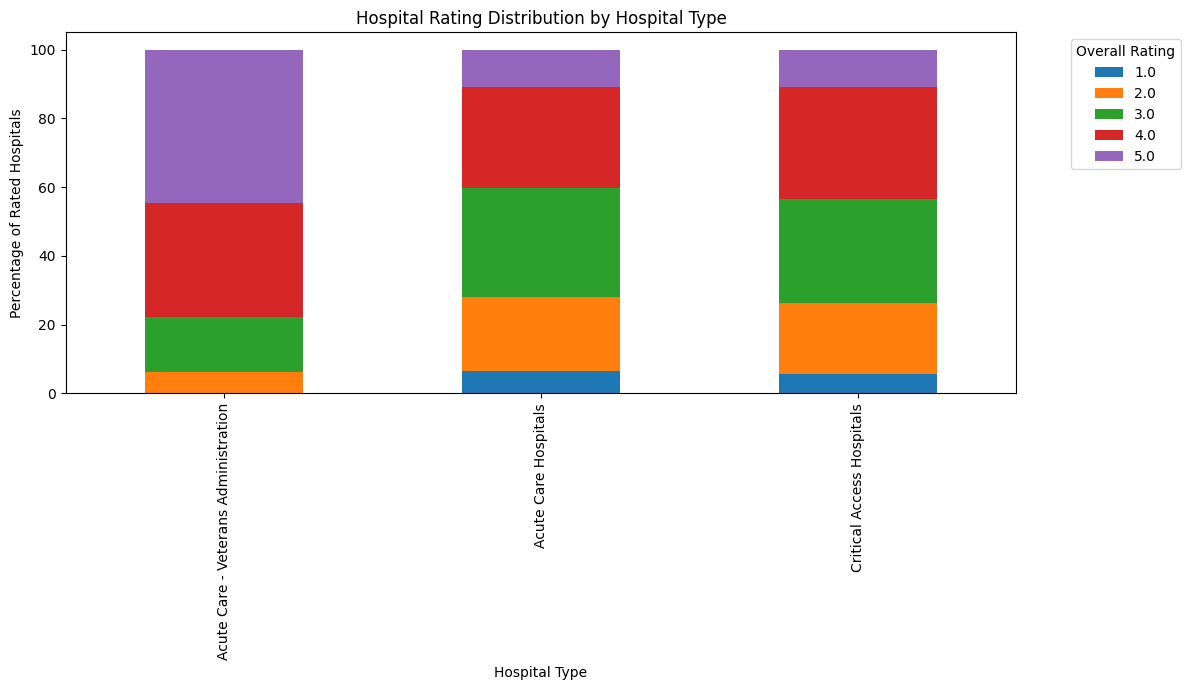

In [ ]:
type_rating_pct.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 7),
    title="Hospital Rating Distribution by Hospital Type"
)

plt.xlabel("Hospital Type")
plt.ylabel("Percentage of Rated Hospitals")
plt.legend(title="Overall Rating", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [ ]:
high_rating = type_rating_pct[[4, 5]].sum(axis=1).sort_values(ascending=False)

print(high_rating.round(1))

Hospital Type
Acute Care - Veterans Administration    77.7
Critical Access Hospitals               43.4
Acute Care Hospitals                    40.2
dtype: float64


In [ ]:
low_rating = type_rating_pct[[1, 2]].sum(axis=1).sort_values(ascending=False)

print(low_rating.round(1))

Hospital Type
Acute Care Hospitals                    28.1
Critical Access Hospitals               26.3
Acute Care - Veterans Administration     6.2
dtype: float64


In [ ]:
emergency_analysis = (
    hospital_df[hospital_df["Hospital overall rating numeric"].notna()]
    .groupby("Emergency Services")["Hospital overall rating numeric"]
    .agg(["count", "mean"])
    .sort_values("mean", ascending=False)
)

print(emergency_analysis)

                    count      mean
Emergency Services                 
No                    153  3.359477
Yes                  3021  3.199272


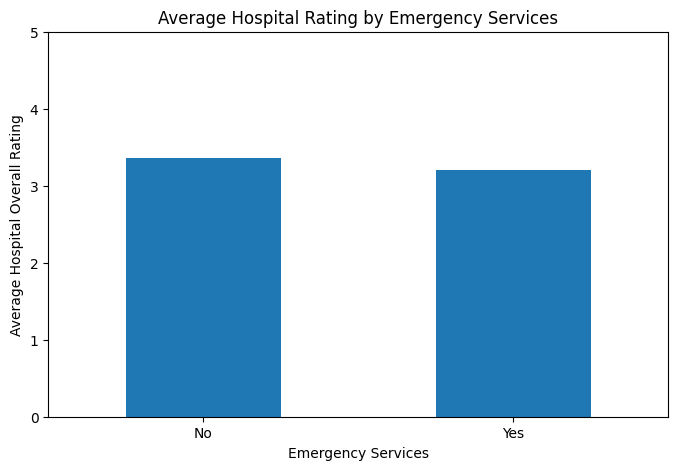

In [ ]:
emergency_analysis["mean"].plot(
    kind="bar",
    figsize=(8, 5),
    title="Average Hospital Rating by Emergency Services"
)

plt.xlabel("Emergency Services")
plt.ylabel("Average Hospital Overall Rating")
plt.ylim(0, 5)
plt.xticks(rotation=0)
plt.show()

# 5. Availability of Hospital Ratings

## Question

How complete is the overall hospital rating data?

Before interpreting hospital ratings, I evaluated how frequently an overall rating was available in the dataset.

## Findings

The dataset contains 5,419 hospitals.

- 3,174 hospitals have an available overall rating.
- 2,245 hospitals are listed as "Not Available."
- Approximately 41.4% of hospitals therefore do not have an available overall rating.

## Interpretation

The high proportion of unavailable ratings is an important limitation when analyzing hospital performance.

Analyses based on average overall ratings represent only the subset of hospitals with an available rating. The results should therefore not be interpreted as representing all hospitals in the dataset.

From an analytics perspective, this demonstrates why data availability and completeness should be evaluated before drawing conclusions from healthcare performance measures.

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import files

uploaded = files.upload()

Saving Hospital_General_Information.csv to Hospital_General_Information.csv


In [5]:
hospital_df = pd.read_csv("Hospital_General_Information.csv")

print("Data loaded successfully!")
print("Rows:", len(hospital_df))
print("Columns:", len(hospital_df.columns))

Data loaded successfully!
Rows: 5419
Columns: 38


In [6]:
# Convert ratings to numeric
hospital_df["Hospital overall rating numeric"] = pd.to_numeric(
    hospital_df["Hospital overall rating"],
    errors="coerce"
)

# Calculate average rating and number of rated hospitals by type
avg_rating_by_type = (
    hospital_df
    .dropna(subset=["Hospital overall rating numeric"])
    .groupby("Hospital Type")["Hospital overall rating numeric"]
    .agg(["count", "mean"])
    .sort_values("mean", ascending=False)
)

avg_rating_by_type

,count,mean
Hospital Type,,
Acute Care - Veterans Administration,112,4.160714
Critical Access Hospitals,399,3.223058
Acute Care Hospitals,2663,3.164476


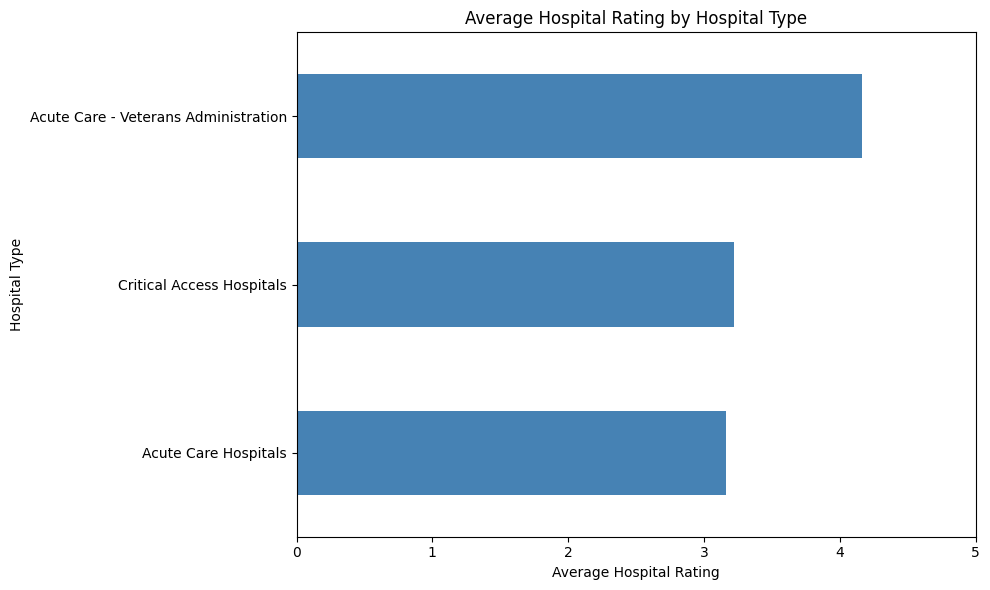

In [7]:
# Keep only hospital types with an available average rating
plot_data = avg_rating_by_type["mean"].dropna().sort_values()

plt.figure(figsize=(10, 6))

plot_data.plot(
    kind="barh",
    color="steelblue"
)

plt.title("Average Hospital Rating by Hospital Type")
plt.xlabel("Average Hospital Rating")
plt.ylabel("Hospital Type")
plt.xlim(0, 5)

plt.tight_layout()
plt.show()

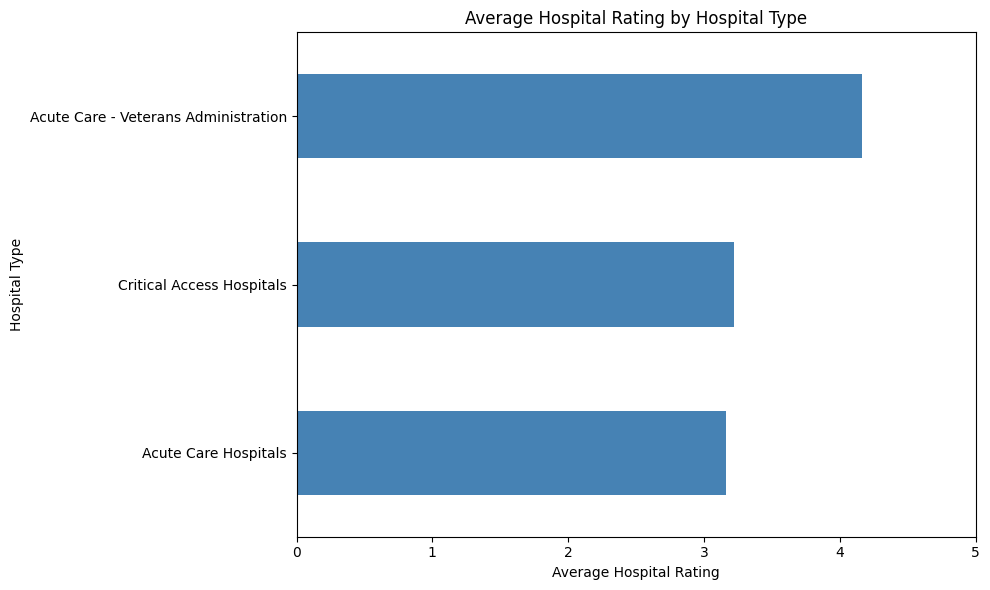

In [8]:
plt.figure(figsize=(10, 6))

plot_data.plot(
    kind="barh",
    color="steelblue"
)

plt.title("Average Hospital Rating by Hospital Type")
plt.xlabel("Average Hospital Rating")
plt.ylabel("Hospital Type")
plt.xlim(0, 5)

plt.tight_layout()

plt.savefig(
    "hospital_ratings_by_type.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [9]:
from google.colab import files

files.download("hospital_ratings_by_type.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>